In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import utils
import torch 
from torch.utils.data import TensorDataset, DataLoader
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn 

In [2]:
global_dataset = pd.read_csv('./datasets/global_test_dataset.csv')
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


In [3]:
### Device setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device
RANDOMSEED = 42
random.seed(RANDOMSEED)
np.random.seed(RANDOMSEED)
torch.manual_seed(RANDOMSEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(RANDOMSEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
### Creating a generator to pass into the data loader 
g = torch.Generator()
g.manual_seed(RANDOMSEED)
batch_size = 64

In [4]:
X = global_dataset.drop(columns ='Label_Binary')
X = X.to_numpy()
y = global_dataset['Label_Binary']
y = y.to_numpy()
X_tensor = torch.tensor(X, dtype = torch.float32)
y_tensor = torch.tensor(y, dtype = torch.long)
global_tuple = TensorDataset(X_tensor,y_tensor)
test_loader = DataLoader(global_tuple, batch_size=batch_size, shuffle=True)

### Loading all the models

In [8]:
centralized_model = utils.loading_pickle('./models/centralized_model.pickle')
centralized_model = centralized_model.to(device)
fed_nova_model = utils.loading_pickle('./models/fednova.pickle')
fed_avg_model = utils.loading_pickle('./models/fedprox.pickle')
fed_prox_model = utils.loading_pickle('./models/fedavg.pickle')

In [9]:
### For model evaluation 
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    total = 0 
    correct = 0 
    true_labels = []
    prediction = []

    with torch.no_grad():
        for samples, features in test_loader:
            samples = samples.to(device)
            features = features.to(device)
            output = model(samples)
            loss = criterion(output, features)
            _, predicted = output.max(1)
            prediction.extend(predicted.tolist())
            total += features.size(0)
            test_loss += loss.item()
            correct += predicted.eq(features).sum().item()
            true_labels.extend(features.tolist())

        test_loss = test_loss/len(test_loader.dataset)
        accuracy = 100* correct / total 
    
    return test_loss, accuracy, prediction, true_labels

In [10]:
### Centralized model 
centralized_test_loss, centralized_accuracy, centralized_prediction, centralized_true_labels = post_trained_global_model(centralized_model, test_loader, criterion, device)
print(centralized_test_loss)
print(centralized_accuracy)
print(classification_report(centralized_true_labels,centralized_prediction))

0.23059371883135807
88.82346598940988
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     83474
           1       0.92      0.85      0.88     83474

    accuracy                           0.89    166948
   macro avg       0.89      0.89      0.89    166948
weighted avg       0.89      0.89      0.89    166948



In [11]:
fed_nova_test_loss, fed_nova_accuracy, fed_nova_prediction, fed_nova_true_labels = post_trained_global_model(fed_nova_model, test_loader, criterion, device)
print(fed_nova_test_loss)
print(fed_nova_accuracy)
print(classification_report(fed_nova_true_labels,fed_nova_prediction))

0.003284214235538578
91.97953853894626
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     83474
           1       0.98      0.86      0.91     83474

    accuracy                           0.92    166948
   macro avg       0.93      0.92      0.92    166948
weighted avg       0.93      0.92      0.92    166948



In [12]:
fed_prox_test_loss, fed_prox_accuracy, fed_prox_prediction, fed_prox_true_labels = post_trained_global_model(fed_prox_model, test_loader, criterion, device)
print(fed_prox_test_loss)
print(fed_prox_accuracy)
print(classification_report(fed_prox_true_labels,fed_prox_prediction))

0.0016037273020672916
96.18144571962527
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     83474
           1       0.99      0.94      0.96     83474

    accuracy                           0.96    166948
   macro avg       0.96      0.96      0.96    166948
weighted avg       0.96      0.96      0.96    166948



In [ ]:
fed_avg_test_loss, fed_avg_accuracy, fed_avg_prediction, fed_avg_true_labels = post_trained_global_model(fed_avg_model, test_loader, criterion, device)
print(fed_avg_test_loss)
print(fed_avg_accuracy)
print(classification_report(fed_avg_true_labels,fed_avg_prediction))

0.0034795888075533406
92.00888899537581
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     83474
           1       0.97      0.87      0.92     83474

    accuracy                           0.92    166948
   macro avg       0.92      0.92      0.92    166948
weighted avg       0.92      0.92      0.92    166948



In [ ]:
def extract_metrics(model_name, y_true, y_pred, test_loss, test_accuracy):

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    return {
        "model": model_name,

        # Class 0 metrics
        "0_precision": report["0"]["precision"],
        "0_recall": report["0"]["recall"],
        "0_f1": report["0"]["f1-score"],

        # Class 1 metrics
        "1_precision": report["1"]["precision"],
        "1_recall": report["1"]["recall"],
        "1_f1": report["1"]["f1-score"],

        # Overall metrics
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],

        # Test metrics
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    }

# Collect all model metrics
results = []

results.append(
    extract_metrics(
        "Centralized",
        centralized_true_labels,
        centralized_prediction,
        centralized_test_loss,
        centralized_accuracy
    )
)

results.append(
    extract_metrics(
        "FedNova",
        fed_nova_true_labels,
        fed_nova_prediction,
        fed_nova_test_loss,
        fed_nova_accuracy
    )
)

results.append(
    extract_metrics(
        "FedProx",
        fed_prox_true_labels,
        fed_prox_prediction,
        fed_prox_test_loss,
        fed_prox_accuracy
    )
)

results.append(
    extract_metrics(
        "FedAvg",
        fed_avg_true_labels,
        fed_avg_prediction,
        fed_avg_test_loss,
        fed_avg_accuracy
    )
)

# Create dataframe
comparison_df = pd.DataFrame(results)

# Optional: round values
comparison_df = comparison_df.round(4)

comparison_df.head(5)

,model,0_precision,0_recall,0_f1,1_precision,1_recall,1_f1,accuracy,macro_f1,weighted_f1,test_loss,test_accuracy
0,Centralized,0.8382,0.9351,0.8840,0.9266,0.8196,0.8698,0.8773,0.8769,0.8769,0.0102,87.7309
1,FedNova,0.8721,0.9839,0.9246,0.9815,0.8557,0.9143,0.9198,0.9195,0.9195,0.0033,91.9795
2,FedProx,0.9407,0.9858,0.9627,0.9851,0.9378,0.9609,0.9618,0.9618,0.9618,0.0016,96.1814
3,FedAvg,0.8814,0.9709,0.9240,0.9676,0.8693,0.9158,0.9201,0.9199,0.9199,0.0035,92.0089


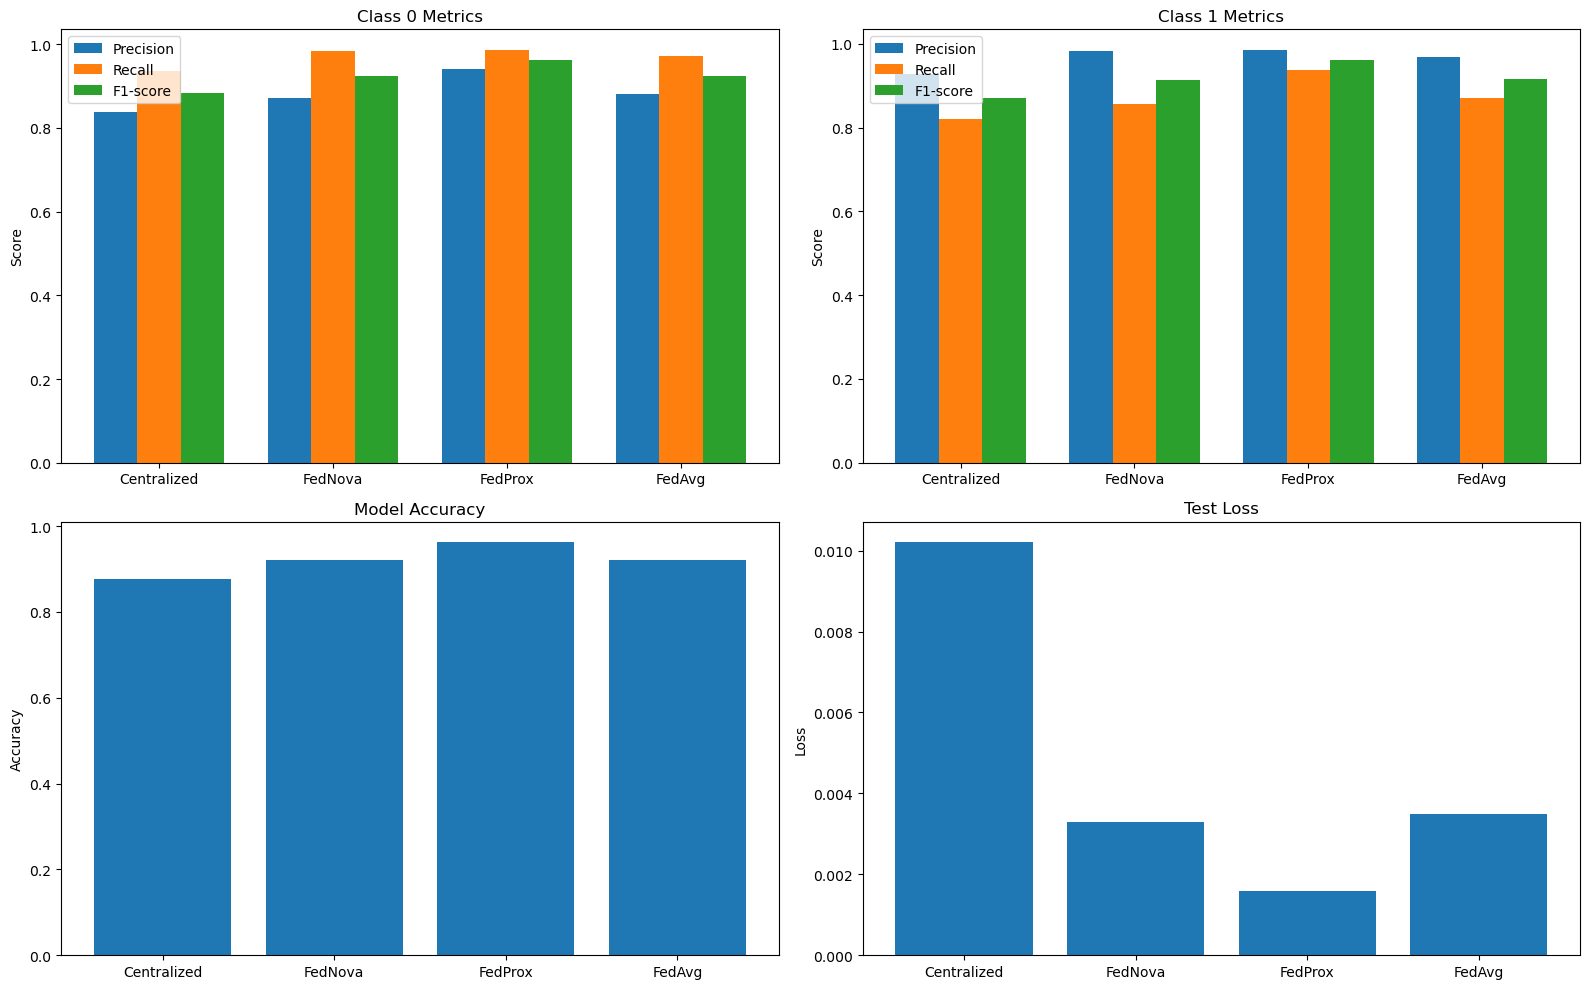

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["model"]


x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].bar(x - width, comparison_df["0_precision"], width, label="Precision")
axes[0,0].bar(x, comparison_df["0_recall"], width, label="Recall")
axes[0,0].bar(x + width, comparison_df["0_f1"], width, label="F1-score")

axes[0,0].set_title("Class 0 Metrics")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models)
axes[0,0].set_ylabel("Score")
axes[0,0].legend()


axes[0,1].bar(x - width, comparison_df["1_precision"], width, label="Precision")
axes[0,1].bar(x, comparison_df["1_recall"], width, label="Recall")
axes[0,1].bar(x + width, comparison_df["1_f1"], width, label="F1-score")

axes[0,1].set_title("Class 1 Metrics")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models)
axes[0,1].set_ylabel("Score")
axes[0,1].legend()

axes[1,0].bar(models, comparison_df["accuracy"])

axes[1,0].set_title("Model Accuracy")
axes[1,0].set_ylabel("Accuracy")

axes[1,1].bar(models, comparison_df["test_loss"])

axes[1,1].set_title("Test Loss")
axes[1,1].set_ylabel("Loss")

plt.tight_layout()
plt.show()